## Libraries


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np   

import sys
import os

sys.path.append(os.path.abspath('..'))  
sys.path.append(os.path.abspath('.'))

from pathlib import Path



In [6]:
from src import EDA_support as sp_eda
from src import EDA_support as sp_eda
from src import colour_palettes_support as pal

## Files load


In [16]:


BASE_DIR = Path().resolve().parent  
df_flights = pd.read_csv(BASE_DIR / "data" / "Raw" / "Customer Flight Activity.csv")
df_profile = pd.read_csv(BASE_DIR / "data" / "Raw" / "Customer Loyalty History.csv")
pd.set_option("display.max_columns", None)

## EDA: Customer Flight Activity

In [8]:
df_flights.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [9]:
print(f"The number of rows we have is {df_flights.shape[0]} and the number of columns is {df_flights.shape[1]}")

The number of rows we have is 405624 and the number of columns is 10


In [17]:
df_flights.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [11]:
round (df_flights.isna().sum()/df_flights.shape[0]*100,2)

#no nulls

Loyalty Number                 0.0
Year                           0.0
Month                          0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
dtype: float64

In [12]:
df_flights.duplicated().sum()

np.int64(1864)

In [13]:
df_flights.duplicated(subset="Loyalty Number").sum()



np.int64(388887)

In [14]:
round(df_flights.duplicated(subset="Loyalty Number").sum()/df_flights.shape[0]*100,2)

#There are duplicated entries because there is a record for each month of activity.  

np.float64(95.87)

In [15]:
df_flights.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


In [16]:
df_flights[df_flights.duplicated(subset="Loyalty Number", keep=False)].sort_values("Loyalty Number").head(10)


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
169010,100018,2017,11,13,1,14,3374,337.0,0,0
135208,100018,2017,9,9,4,13,1651,165.0,0,0
50703,100018,2017,4,4,0,4,924,92.0,0,0
287317,100018,2018,6,0,0,0,0,0.0,0,0
152109,100018,2017,10,6,0,6,1032,103.0,0,0
213311,100018,2017,3,14,3,17,2533,253.0,438,36
371822,100018,2018,11,11,0,11,3058,305.0,0,0
388723,100018,2018,12,17,6,23,4945,494.0,0,0
185911,100018,2017,12,6,0,6,1908,190.0,0,0
338020,100018,2018,9,14,2,16,3568,356.0,0,0


In [17]:
df_flights["Loyalty Number"].value_counts(dropna=False, normalize=True)*100

Loyalty Number
678205    0.017750
499874    0.011834
411734    0.011834
255475    0.011834
528447    0.011834
            ...   
101515    0.005917
101540    0.005917
101544    0.005917
101547    0.005917
999891    0.005917
Name: proportion, Length: 16737, dtype: float64

In [18]:
df_flights["Loyalty Number"].unique()

array([100018, 100102, 100140, ..., 999731, 999788, 999891])

DESCRIPTIVE STATISTICS 

The minimum value for Loyalty Number is 100018
The maximum of Loyalty Number is 999986
The mean of Loyalty Number is 550037.8730844329
The median of Loyalty Number is 550834.0
--------------------
DESCRIBE :
 count    405624.000000
mean     550037.873084
std      258935.286969
min      100018.000000
25%      326961.000000
50%      550834.000000
75%      772194.000000
max      999986.000000
Name: Loyalty Number, dtype: float64 

--------------------


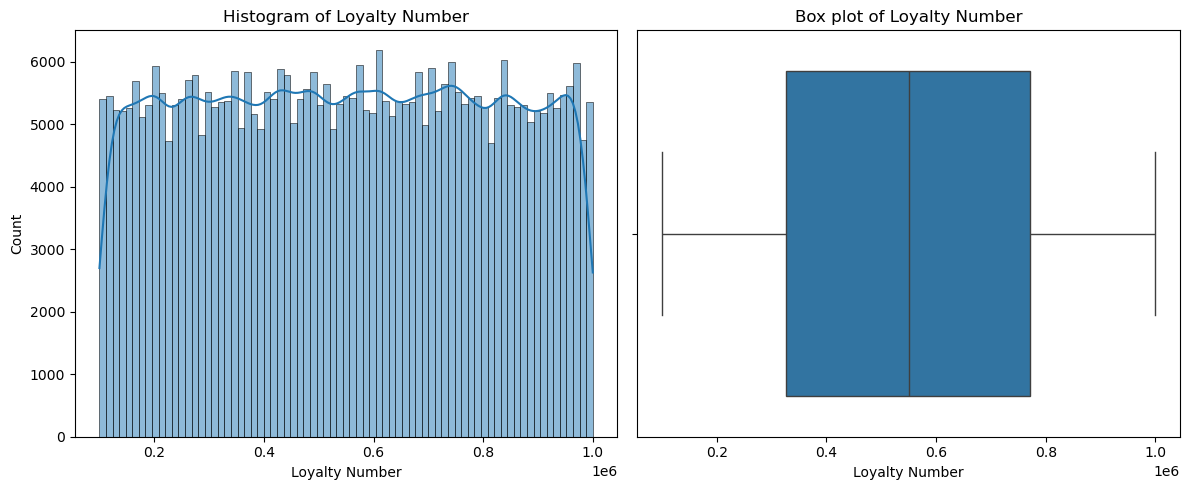

In [19]:
sp_eda.numerical_exploration(df_flights, "Loyalty Number" )

## EDA: Customer Loyalty History

In [20]:
df_profile.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [21]:
print(f"The number of rows is {df_profile.shape[0]} and the number of columns is {df_profile.shape[1]}")

The number of rows is 16737 and the number of columns is 16


In [22]:
df_profile.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [23]:
round (df_profile.isna().sum()/df_profile.shape[0]*100,2)

#null in Cancellation because the customers are still active


Loyalty Number         0.00
Country                0.00
Province               0.00
City                   0.00
Postal Code            0.00
Gender                 0.00
Education              0.00
Salary                25.32
Marital Status         0.00
Loyalty Card           0.00
CLV                    0.00
Enrollment Type        0.00
Enrollment Year        0.00
Enrollment Month       0.00
Cancellation Year     87.65
Cancellation Month    87.65
dtype: float64

In [24]:
df_profile.duplicated().sum()

np.int64(0)

In [25]:
df_profile.describe().T


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


In [26]:
df_profile["Loyalty Number"].value_counts(dropna=False, normalize=True)*100

Loyalty Number
652627    0.005975
954587    0.005975
909547    0.005975
464394    0.005975
154981    0.005975
            ...   
530508    0.005975
193662    0.005975
927943    0.005975
188893    0.005975
852392    0.005975
Name: proportion, Length: 16737, dtype: float64

In [27]:
df_profile["Loyalty Number"].unique()

array([480934, 549612, 429460, ..., 776187, 906428, 652627])

DESCRIPTIVE STATISTICS 

The minimum value for Loyalty Number is 100018
The maximum of Loyalty Number is 999986
The mean of Loyalty Number is 549735.8804445241
The median of Loyalty Number is 550434.0
--------------------
DESCRIBE :
 count     16737.000000
mean     549735.880445
std      258912.132453
min      100018.000000
25%      326603.000000
50%      550434.000000
75%      772019.000000
max      999986.000000
Name: Loyalty Number, dtype: float64 

--------------------


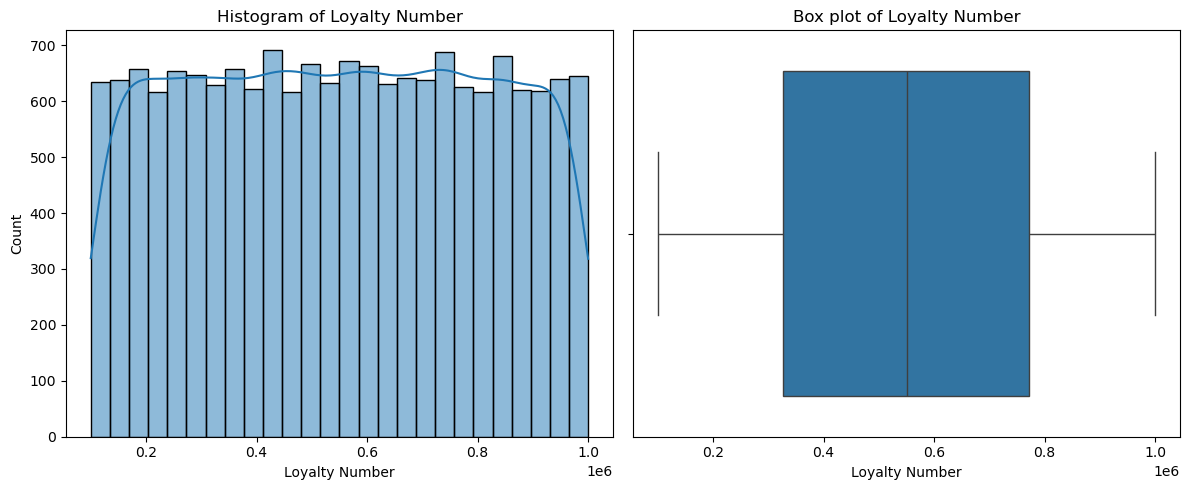

In [28]:
sp_eda.numerical_exploration(df_profile, "Loyalty Number" )

## Dataframes merge

In [29]:
df_merged = pd.merge(
    df_profile, 
    df_flights, 
    on='Loyalty Number', 
    how='left' 
)


## Transformations

## EDA:  merged 

In [30]:
df_merged.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,1,0,0,0,0,0.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,3,0,0,0,0,0.0,0,0
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2017,4,0,0,0,0,0.0,0,0
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2018,10,6,2,8,3352,335.0,465,38


In [31]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Country                      405624 non-null  object 
 2   Province                     405624 non-null  object 
 3   City                         405624 non-null  object 
 4   Postal Code                  405624 non-null  object 
 5   Gender                       405624 non-null  object 
 6   Education                    405624 non-null  object 
 7   Salary                       302952 non-null  float64
 8   Marital Status               405624 non-null  object 
 9   Loyalty Card                 405624 non-null  object 
 10  CLV                          405624 non-null  float64
 11  Enrollment Type              405624 non-null  object 
 12  Enrollment Year              405624 non-null  int64  
 13 

In [32]:
print(f"The number of rows is {df_merged.shape[0]} and the number of columns is {df_merged.shape[1]}")

#The number of rows in the flight log remains the same; columns have been added. Merge verified 

The number of rows is 405624 and the number of columns is 25


In [33]:
df_merged.isna().sum()

Loyalty Number                      0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                         102672
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              355560
Cancellation Month             355560
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
dtype: int64

In [34]:
round(df_merged.isna().sum()/df_merged.shape[0]*100,2)

Loyalty Number                  0.00
Country                         0.00
Province                        0.00
City                            0.00
Postal Code                     0.00
Gender                          0.00
Education                       0.00
Salary                         25.31
Marital Status                  0.00
Loyalty Card                    0.00
CLV                             0.00
Enrollment Type                 0.00
Enrollment Year                 0.00
Enrollment Month                0.00
Cancellation Year              87.66
Cancellation Month             87.66
Year                            0.00
Month                           0.00
Flights Booked                  0.00
Flights with Companions         0.00
Total Flights                   0.00
Distance                        0.00
Points Accumulated              0.00
Points Redeemed                 0.00
Dollar Cost Points Redeemed     0.00
dtype: float64

In [35]:
df_merged.duplicated().sum()

np.int64(1864)

In [36]:
df_merged.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.00,326961.00,550834.00,772194.00,999986.00
Salary,302952.0,79268.825953,34992.133508,-58486.00,59262.00,73479.00,88612.00,407228.00
CLV,405624.0,7991.976226,6863.663857,1898.01,3985.32,5776.34,8936.82,83325.38
Enrollment Year,405624.0,2015.252529,1.979427,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,405624.0,6.668008,3.399766,1.00,4.00,7.00,10.00,12.00
Cancellation Year,50064.0,2016.499521,1.384336,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,50064.0,6.966443,3.448300,1.00,4.00,7.00,10.00,12.00
Year,405624.0,2017.500000,0.500001,2017.00,2017.00,2017.50,2018.00,2018.00
Month,405624.0,6.500000,3.452057,1.00,3.75,6.50,9.25,12.00
Flights Booked,405624.0,4.115052,5.225518,0.00,0.00,1.00,8.00,21.00


In [37]:
df_merged.describe(include="O").T

,count,unique,top,freq
Country,405624,1,Canada,405624
Province,405624,11,Ontario,130896
City,405624,29,Toronto,81096
Postal Code,405624,55,V6E 3D9,21984
Gender,405624,2,Female,203640
Education,405624,5,Bachelor,253752
Marital Status,405624,3,Married,235800
Loyalty Card,405624,3,Star,184224
Enrollment Type,405624,2,Standard,382200


## EDA: A detailed examination of the insights obtained in the previous phase

In [38]:
#next steps

# RELACIÓN ENTRE CLV Y LOYALTY CARD, SALARY 

### Nulls "Salary"

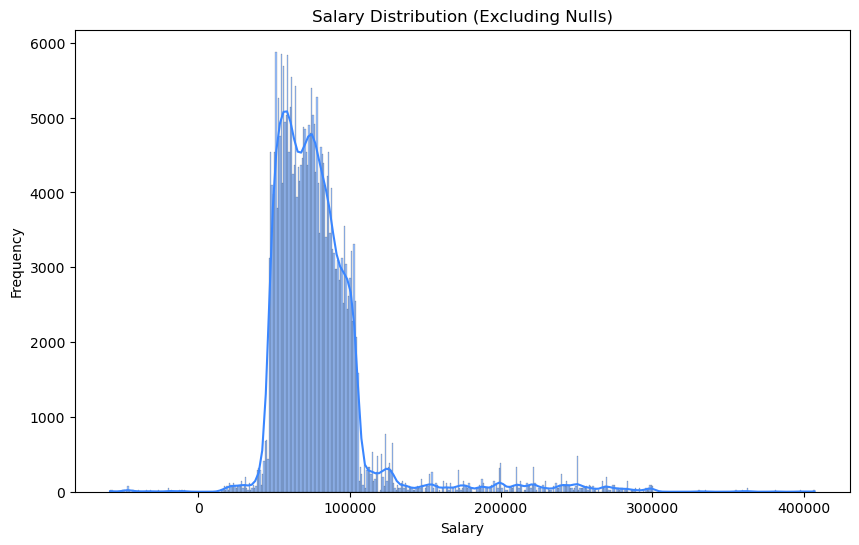

In [39]:

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_merged.dropna(subset=["Salary"]), 
    x="Salary", 
    kde=True,
    color= pal.ocean_blue_serenity["Ocean_Blue"]
)
plt.title("Salary Distribution (Excluding Nulls)")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

C:\Users\micae\AppData\Local\Temp\ipykernel_31768\609459504.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


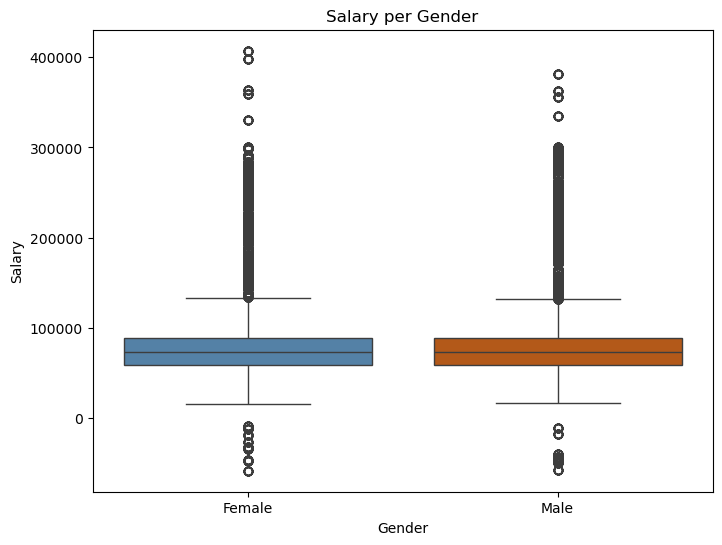

In [42]:

 
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_merged,
    x='Gender', 
    y='Salary',
    palette= [pal.crimson_coast["Slate_Blue"], pal.crimson_coast["Burnt_Orange"]]
)
plt.title('Salary per Gender')
plt.show()


C:\Users\micae\AppData\Local\Temp\ipykernel_31768\1473972122.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


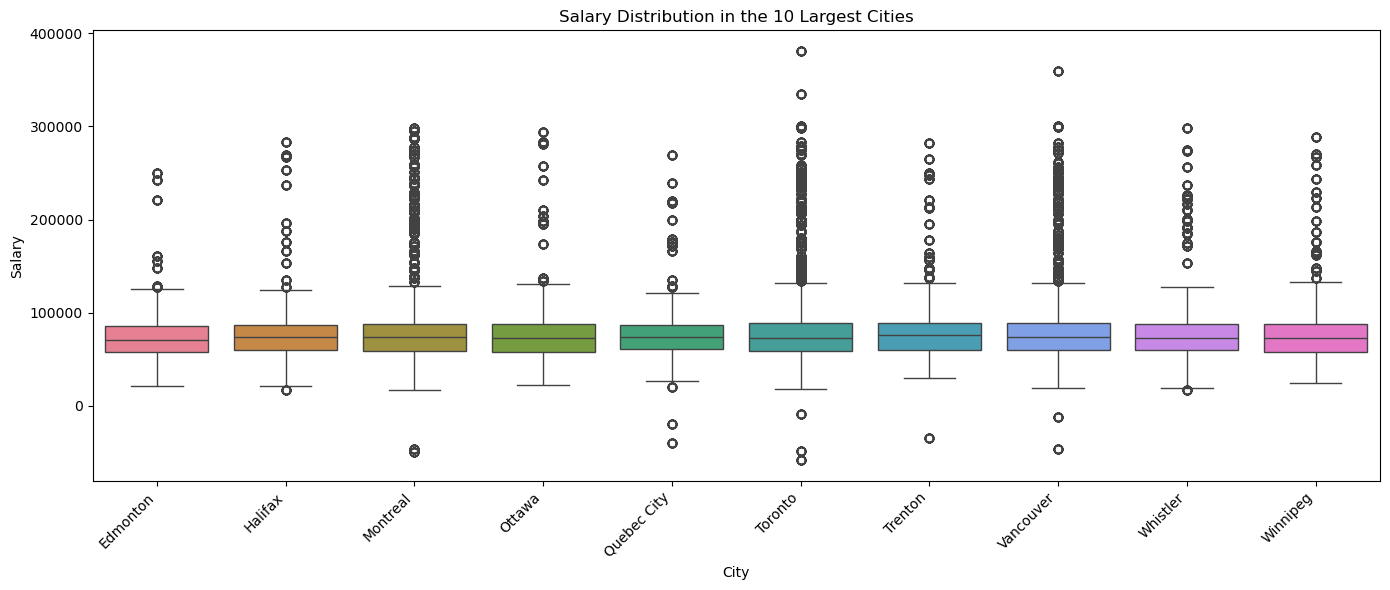

In [43]:
top_cities = df_merged['City'].value_counts().nlargest(10).index
df_top_cities = df_merged[df_merged['City'].isin(top_cities)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top_cities.sort_values('City'),
    x='City', 
    y='Salary',
    palette=sns.color_palette("husl", n_colors=10)
)
plt.title('Salary Distribution in the 10 Largest Cities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\micae\AppData\Local\Temp\ipykernel_31768\4224738950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


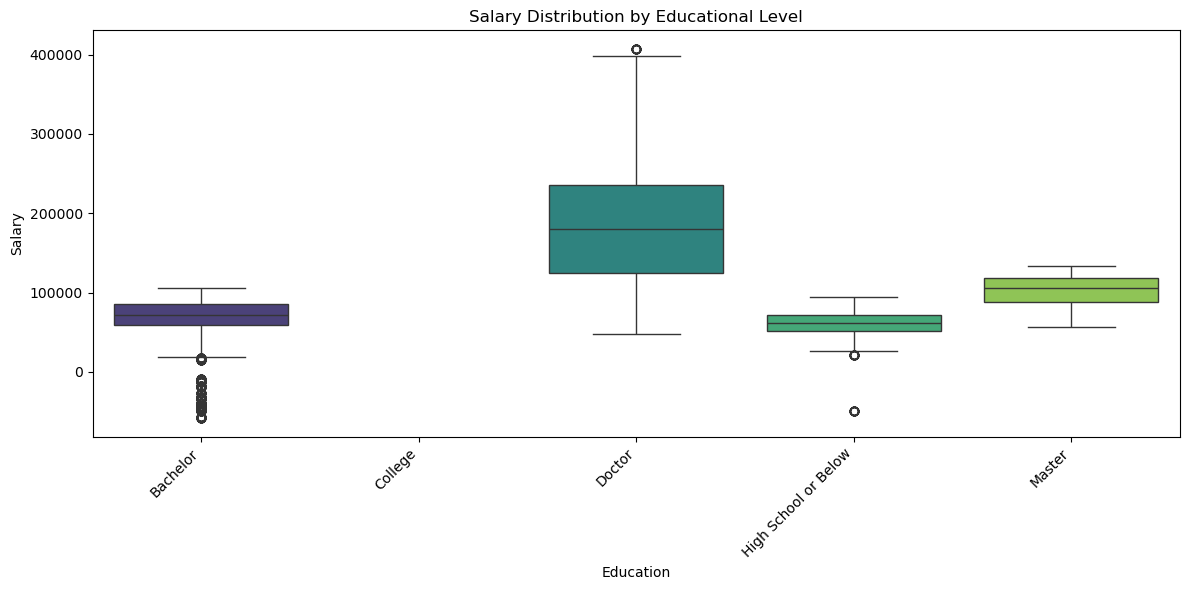

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_merged.sort_values('Education'), 
    x='Education', 
    y='Salary',
    palette=sns.color_palette("viridis", n_colors=len(df_merged['Education'].unique()))
)
plt.title('Salary Distribution by Educational Level')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

#College is missing

In [47]:

# 1. Calculate the mean salary for each education level
df_sorted = df_merged.groupby("Education")["Salary"].mean().reset_index()

# 2. Sort the education levels by mean salary (ascending)
df_sorted = df_sorted.sort_values(by="Salary")

# 3. Extract the order for the graph (X-axis)
education_order = df_sorted["Education"].tolist()

C:\Users\micae\AppData\Local\Temp\ipykernel_31768\1945827709.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


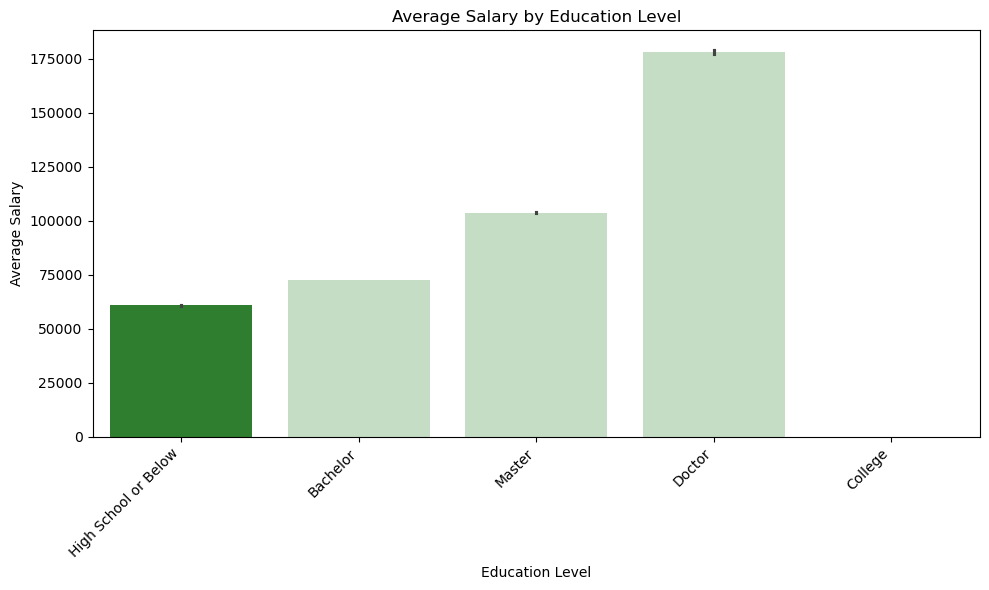

In [ ]:
plt.figure(figsize=(10, 6))


graphic_colors = [pal.earthy_green_tones["Forest_Green"] if level == 'High School or Below' else pal.earthy_green_tones["Soft_Mint_Green"] for level in education_order]

sns.barplot(
    data=df_merged,
    x='Education',
    y='Salary',
    order=education_order,    
    estimator=np.mean,         
    palette=graphic_colors 
)

plt.title('Average Salary by Education Level')
plt.ylabel('Average Salary')
plt.xlabel('Education Level')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

C:\Users\micae\AppData\Local\Temp\ipykernel_31768\2491735149.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


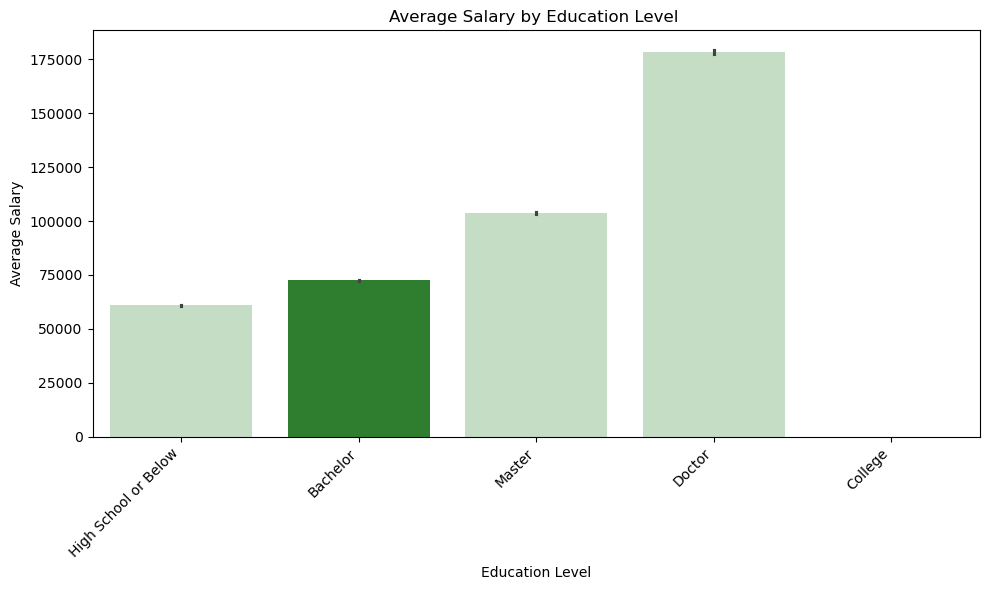

In [50]:
plt.figure(figsize=(10, 6))

graphic_colors = [pal.earthy_green_tones["Forest_Green"] if level == 'Bachelor' else pal.earthy_green_tones["Soft_Mint_Green"] for level in education_order]

sns.barplot(
    data=df_merged,
    x='Education',
    y='Salary',
    order=education_order,     
    estimator=np.mean,        
    palette=graphic_colors 
)

plt.title('Average Salary by Education Level ')
plt.ylabel('Average Salary')
plt.xlabel('Education Level')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

C:\Users\micae\AppData\Local\Temp\ipykernel_31768\3691152307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


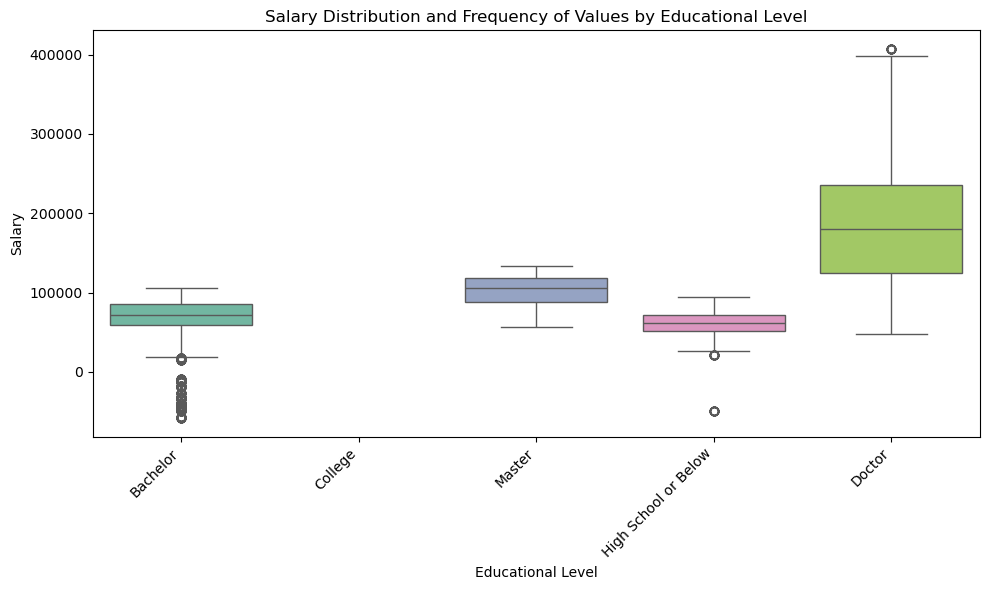

In [52]:


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_merged,
    x='Education',
    y='Salary',
    palette='Set2' 
)
plt.title('Salary Distribution and Frequency of Values by Educational Level')
plt.ylabel('Salary')
plt.xlabel('Educational Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Assigning null values to ‘Salary’ when the “College” value in ‘Education’ is null:

The midpoint between the upper and lower values: ‘High School’ or below and ‘Bachelor's degree’: ‘College’ lies in the middle.

In [53]:
reference_levels = ['Bachelor', 'High School or Below']

mean_reference_salary = df_merged.loc[
    df_merged['Education'].isin(reference_levels), 
    'Salary'
].mean()

print(f"Calculated Mean Reference Salary: {mean_reference_salary:,.2f}")

Calculated Mean Reference Salary: 71,675.52


In [54]:
mask = (df_merged['Education'] == 'College') & (df_merged['Salary'].isna())

df_merged.loc[mask, 'Salary'] = mean_reference_salary

print("Replacement completed: only the “College” null values were assigned.")

Replacement completed: only the “College” null values were assigned.


In [55]:
df_merged["Education"].isna().sum()

np.int64(0)

In [56]:
df_merged.isna().sum()

Loyalty Number                      0
Country                             0
Province                            0
City                                0
Postal Code                         0
Gender                              0
Education                           0
Salary                              0
Marital Status                      0
Loyalty Card                        0
CLV                                 0
Enrollment Type                     0
Enrollment Year                     0
Enrollment Month                    0
Cancellation Year              355560
Cancellation Month             355560
Year                                0
Month                               0
Flights Booked                      0
Flights with Companions             0
Total Flights                       0
Distance                            0
Points Accumulated                  0
Points Redeemed                     0
Dollar Cost Points Redeemed         0
dtype: int64

### Nulos "Cancellation Year" y "Cancellation Month"

Cancellation inactivity imputation (these are active users): Replaced by 0
- Indicates that ‘the cancellation has not yet taken place’
- Allows conversion from NaN to 0. Allows conversion from float to int, such as for enrolment.

In [58]:
cancellation_columns = ['Cancellation Year', 'Cancellation Month']

df_merged[cancellation_columns] = df_merged[cancellation_columns].fillna(0)

#We convert the columns to the integer (int) data type, as years and months are integers. 
df_merged[cancellation_columns] = df_merged[cancellation_columns].astype(int)

print(f"{cancellation_columns} columns cleaned and converted to integers (0 = Active).")

['Cancellation Year', 'Cancellation Month'] columns cleaned and converted to integers (0 = Active).


In [59]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Country                      405624 non-null  object 
 2   Province                     405624 non-null  object 
 3   City                         405624 non-null  object 
 4   Postal Code                  405624 non-null  object 
 5   Gender                       405624 non-null  object 
 6   Education                    405624 non-null  object 
 7   Salary                       405624 non-null  float64
 8   Marital Status               405624 non-null  object 
 9   Loyalty Card                 405624 non-null  object 
 10  CLV                          405624 non-null  float64
 11  Enrollment Type              405624 non-null  object 
 12  Enrollment Year              405624 non-null  int64  
 13 

In [61]:
df_merged.isna().sum()
#no nulls check

Loyalty Number                 0
Country                        0
Province                       0
City                           0
Postal Code                    0
Gender                         0
Education                      0
Salary                         0
Marital Status                 0
Loyalty Card                   0
CLV                            0
Enrollment Type                0
Enrollment Year                0
Enrollment Month               0
Cancellation Year              0
Cancellation Month             0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

### Conversión tipo dato

In [62]:
#‘Cancellation Year’ and ‘Cancellation Month’ have already been changed from float to int when the null values were assigned. 

In [64]:
#‘Points Redeemed’ are indeed whole numbers, usually in the hundreds. 
#It seems that ‘Points Accumulated’ is a float, either due to a typing error or because the airline provides decimal numbers, but can they be spent later? 
#Truncate the number and remove the decimals, or round it off. Points that have already been spent are whole numbers. 


In [65]:
df_merged["Points Accumulated"].unique()[100:200]



array([364.  , 242.  , 540.  , 252.  , 230.04, 319.  , 255.  , 238.68,
       298.08, 421.  , 380.  ,  78.  , 299.  , 191.  , 280.  , 394.  ,
       189.  , 369.  , 284.04, 128.  , 289.  , 343.  , 143.64, 327.24,
       445.  , 183.  ,  55.  , 141.  , 259.  , 428.  , 160.  , 249.  ,
       436.  , 405.  , 150.  , 326.16, 308.88, 345.  , 283.  , 248.  ,
       377.  , 182.  , 430.92, 303.  ,  95.04, 233.28,  63.  , 324.  ,
       228.  ,  19.  ,  88.  , 482.  ,  32.  ,  91.  , 378.  , 352.  ,
       215.  , 384.  , 105.84, 125.28, 150.12, 227.  , 488.  ,  84.  ,
       291.  , 455.  , 313.  , 245.  , 184.68, 309.  , 116.  , 130.68,
       271.  , 140.4 , 396.36, 224.  , 462.  , 306.  , 188.  , 187.  ,
       451.  , 241.  , 382.  , 490.  , 111.  , 390.  , 203.04, 376.92,
       367.  , 246.  , 478.  , 244.  , 312.  ,  99.  , 158.  , 336.  ,
       294.  , 320.  , 132.84, 322.  ])

Redondeo de puntos y conversión a int.

In [71]:
df_merged["Points Accumulated"] = df_merged["Points Accumulated"].round(0)

df_merged["Points Accumulated"] = df_merged["Points Accumulated"].astype(int)

print("The “Points Accumulated” column has been rounded and converted to integer (int).")

The “Points Accumulated” column has been rounded and converted to integer (int).


In [73]:
df_merged["Points Accumulated"]

0           0
1         282
2           0
3           0
4         335
         ... 
405619      0
405620      0
405621      0
405622      0
405623      0
Name: Points Accumulated, Length: 405624, dtype: int64

## Guardado CSV limpio

In [74]:
df_merged.to_csv("Customer Flight Profile_clean.csv", index= False)